<a href="https://colab.research.google.com/github/dgylayse/AkademiQ_DataScience/blob/main/AkademiQ_Data_Science_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv("healthcare_dataset.csv")

secili = ["Age", "Billing Amount", "Admission Type", "Medical Condition", "Test Results"]
print(df.shape)
print(df["Medical Condition"].values)

(27707, 15)
['Cancer' 'Obesity' 'Obesity' ... 'Hypertension' 'Asthma' 'Obesity']


In [2]:
df.drop_duplicates(inplace=True)
print(df.shape)

(27707, 15)


In [3]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df["length of stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days
print(df["length of stay"])

0         2
1         6
2        15
3        30
4        20
         ..
27702    17
27703    28
27704    29
27705    13
27706     1
Name: length of stay, Length: 27707, dtype: int64


In [4]:
kategorik = ["Admission Type", "Medical Condition", "Test Results"]

df_enc = pd.get_dummies(df[secili + ["length of stay"]], columns= kategorik)
print(df_enc.shape)
print(df_enc.columns.tolist()[:8])

(27707, 15)
['Age', 'Billing Amount', 'length of stay', 'Admission Type_Elective', 'Admission Type_Emergency', 'Admission Type_Urgent', 'Medical Condition_Arthritis', 'Medical Condition_Asthma']


In [5]:
print(df_enc.head().astype(int))

   Age  Billing Amount  length of stay  Admission Type_Elective  \
0   30           18856               2                        0   
1   62           33643               6                        0   
2   76           27955              15                        0   
3   28           37909              30                        1   
4   43           14238              20                        0   

   Admission Type_Emergency  Admission Type_Urgent  \
0                         0                      1   
1                         1                      0   
2                         1                      0   
3                         0                      0   
4                         0                      1   

   Medical Condition_Arthritis  Medical Condition_Asthma  \
0                            0                         0   
1                            0                         0   
2                            0                         0   
3                            0  

In [6]:
print(df_enc.iloc[0])

Age                                         30
Billing Amount                    18856.281306
length of stay                               2
Admission Type_Elective                  False
Admission Type_Emergency                 False
Admission Type_Urgent                     True
Medical Condition_Arthritis              False
Medical Condition_Asthma                 False
Medical Condition_Cancer                  True
Medical Condition_Diabetes               False
Medical Condition_Hypertension           False
Medical Condition_Obesity                False
Test Results_Abnormal                    False
Test Results_Inconclusive                False
Test Results_Normal                       True
Name: 0, dtype: object


# KMeans Kurgusu

In [7]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df_enc)
print(X.mean(axis=0).round(2))
print(X.std(axis=0).round(2))

[ 0. -0. -0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0. -0.  0.]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42, n_init=10)

df["kume"] = km.fit_predict(X)
print(df["kume"].value_counts())

kume
0    9314
1    9200
2    9193
Name: count, dtype: int64


In [9]:
inertia=[]

for k in range(2,9):
  inertia.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_)

print([round(i) for i in inertia])

[374072, 332467, 324628, 282500, 249335, 242292, 236489]


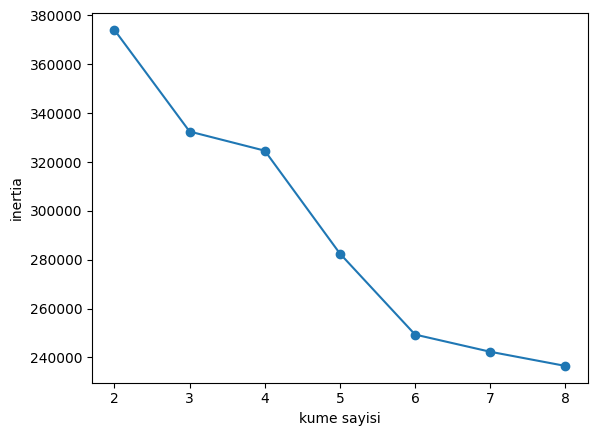

In [10]:
import matplotlib.pyplot as plt
plt.plot(range(2,9), inertia, "o-")
plt.xlabel("kume sayisi"); plt.ylabel("inertia"); plt.show()

In [12]:
from sklearn.metrics import silhouette_score

for k in range(2,7):
 etiket = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
 print(k, round(silhouette_score(X, etiket, sample_size=5000),3))

2 0.104
3 0.155
4 0.146
5 0.222
6 0.266
